In [18]:
import pandas as pd
df = pd.read_csv(r"..\dataset\dataset_module_one_DM2.csv")

## Setup Dati

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Assuming 'sii' is the target column
X = df.drop(columns=['sii'])
y = df['sii']

# Map actual class IDs (e.g., 0: 5000, 1: 1500, 2: 900, 3: 80)
class_labels = [0, 1, 2, 3] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Pipeline & SMOTE

In [20]:
# Target definition mapping class IDs to desired sample counts
smote_strategy = {
    0: 5000,  # Majority class intact
    1: 2000,  # Intermediate 1
    2: 2000,  # Intermediate 2
    3: 1500   # Minority class
}

smote = SMOTE(sampling_strategy=smote_strategy, random_state=42)

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('smote', smote),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# AdaBoost Pipeline
ab_pipeline = Pipeline([
    ('smote', smote),
    ('ab', AdaBoostClassifier(random_state=42))
])

## Hyper parameter Tuning

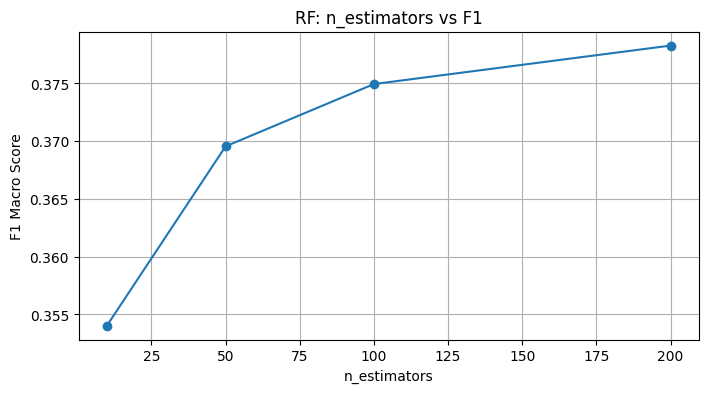

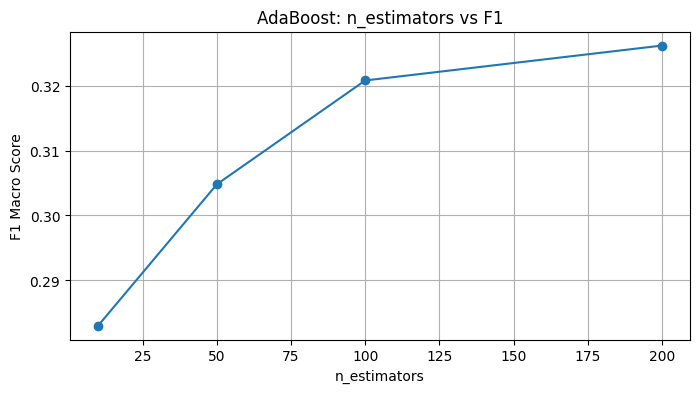

In [ ]:
# Parameter grids
rf_param_grid = {
    'rf__n_estimators': [10, 50, 100, 200],
    'rf__max_depth': [None, 10, 20]
}

ab_param_grid = {
    'ab__n_estimators': [10, 50, 100, 200],
    'ab__learning_rate': [0.1, 0.5, 1.0]
}

# Grid searches
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, scoring='f1_macro', cv=5, n_jobs=-1)
ab_grid = GridSearchCV(ab_pipeline, ab_param_grid, scoring='f1_macro', cv=5, n_jobs=-1)

rf_grid.fit(X_train, y_train)
ab_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
best_ab = ab_grid.best_estimator_

def plot_n_estimators_impact(grid, prefix, title):
    results = pd.DataFrame(grid.cv_results_)
    
    # Add 'param_' to match Scikit-Learn's cv_results_ format
    param_col = f'param_{prefix}__n_estimators'
    
    # Max score for each n_estimators value
    scores = results.groupby(param_col)['mean_test_score'].max()
    
    plt.figure(figsize=(8, 4))
    plt.plot(scores.index, scores.values, marker='o')
    plt.title(title)
    plt.xlabel('n_estimators')
    plt.ylabel('F1 Macro Score')
    plt.grid(True)
    plt.show()

# Visualize
plot_n_estimators_impact(rf_grid, 'rf', 'RF: n_estimators vs F1')
plot_n_estimators_impact(ab_grid, 'ab', 'AdaBoost: n_estimators vs F1')

## Valutazione

--- Classification Report: Random Forest ---
              precision    recall  f1-score   support

         0.0       0.79      0.78      0.78      1158
         1.0       0.27      0.23      0.25       315
         2.0       0.25      0.32      0.28       188
         3.0       0.10      0.12      0.11        16

    accuracy                           0.62      1677
   macro avg       0.35      0.37      0.36      1677
weighted avg       0.63      0.62      0.62      1677

--- Classification Report: AdaBoost ---
              precision    recall  f1-score   support

         0.0       0.75      0.90      0.82      1158
         1.0       0.37      0.11      0.17       315
         2.0       0.35      0.34      0.34       188
         3.0       0.00      0.00      0.00        16

    accuracy                           0.68      1677
   macro avg       0.37      0.34      0.33      1677
weighted avg       0.63      0.68      0.64      1677



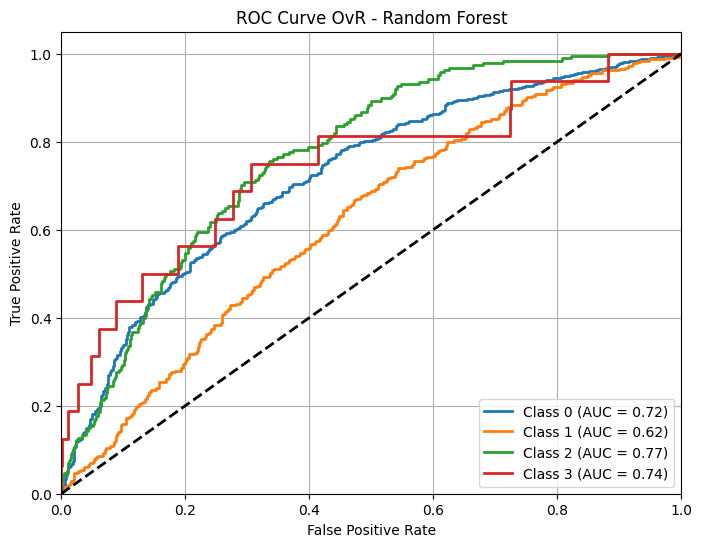

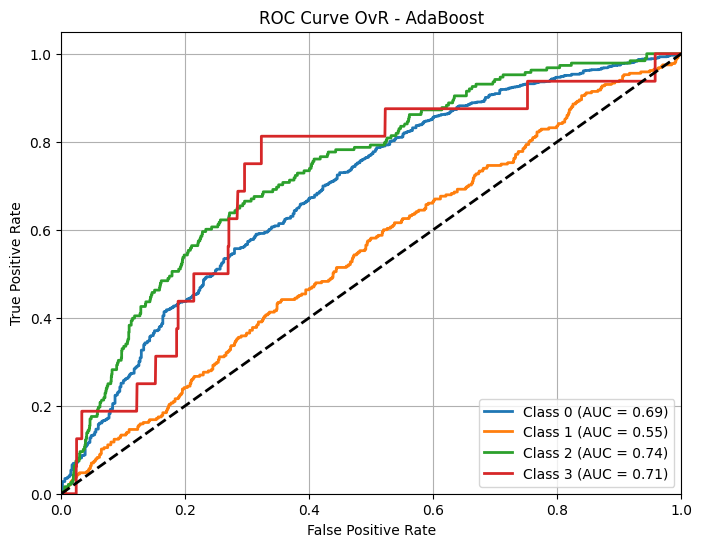

In [26]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"--- Classification Report: {model_name} ---")
    print(classification_report(y_test, y_pred))

evaluate_model(best_rf, X_test, y_test, "Random Forest")
evaluate_model(best_ab, X_test, y_test, "AdaBoost")

def plot_multiclass_roc(model, X_test, y_test, class_labels, model_name):
    y_test_bin = label_binarize(y_test, classes=class_labels)
    n_classes = y_test_bin.shape[1]
    y_score = model.predict_proba(X_test)

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {class_labels[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve OvR - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Uncomment to visualize
plot_multiclass_roc(best_rf, X_test, y_test, class_labels, "Random Forest")
plot_multiclass_roc(best_ab, X_test, y_test, class_labels, "AdaBoost")

## Feature importance

In [ ]:
# Extract RF model from best pipeline
rf_model = best_rf.named_steps['rf']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances - Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

NameError: name 'best_xgb' is not defined